# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

Updated Corpus


In [2]:
corpus = '''Cristiano Ronaldo is widely regarded as one of the greatest football players of all time. Born on February 5, 1985, in Funchal, Madeira, Portugal, Ronaldo showed exceptional talent and determination from a young age. Despite growing up in modest circumstances, he worked tirelessly to pursue his dream of becoming a professional footballer. At the age of 12, he moved to Lisbon and joined the youth academy of Sporting CP, where his remarkable skills and dedication quickly earned recognition. His performances attracted the attention of Manchester United, where he developed into one of the world's finest players. Over the years, Ronaldo also enjoyed successful spells with Real Madrid, Juventus, and later returned to Manchester United before joining Al Nassr. His incredible speed, athleticism, finishing ability, and leadership qualities have made him one of the most complete footballers in history.

Throughout his career, Ronaldo has won multiple Ballon d'Or awards, recognizing him as one of the best football players in the world. He has broken numerous records, including becoming one of the highest goal scorers in football history and the leading scorer in international men's football. Beyond his individual achievements, Ronaldo has consistently demonstrated a strong commitment to his teams and a relentless desire to succeed. One of the most memorable moments of his career came in 2016 when he captained the Portugal national team to victory in the UEFA European Championship, securing Portugal's first major international trophy. He later helped Portugal win the UEFA Nations League in 2019, further strengthening his legacy.

Apart from football, Ronaldo is admired for his discipline, work ethic, and charitable contributions. He has supported various humanitarian causes and donated generously to hospitals, children's organizations, and disaster relief efforts. His inspiring journey from a young boy with big dreams to a global football icon continues to motivate millions of people around the world.'''

print(corpus)

Cristiano Ronaldo is widely regarded as one of the greatest football players of all time. Born on February 5, 1985, in Funchal, Madeira, Portugal, Ronaldo showed exceptional talent and determination from a young age. Despite growing up in modest circumstances, he worked tirelessly to pursue his dream of becoming a professional footballer. At the age of 12, he moved to Lisbon and joined the youth academy of Sporting CP, where his remarkable skills and dedication quickly earned recognition. His performances attracted the attention of Manchester United, where he developed into one of the world's finest players. Over the years, Ronaldo also enjoyed successful spells with Real Madrid, Juventus, and later returned to Manchester United before joining Al Nassr. His incredible speed, athleticism, finishing ability, and leadership qualities have made him one of the most complete footballers in history.

Throughout his career, Ronaldo has won multiple Ballon d'Or awards, recognizing him as one of

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 193
X shape: (303, 137)
y shape: (303,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [7]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [9]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

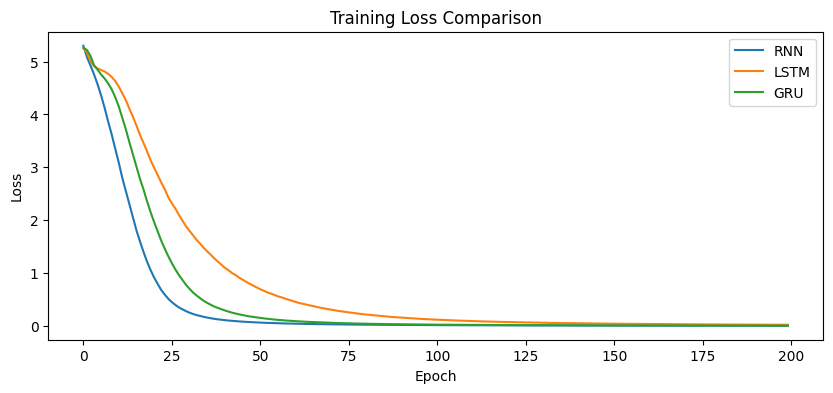

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [12]:
print("RNN :", generate_text(rnn_model, "One of the most memorable moments of his career came", 5))
print("LSTM:", generate_text(lstm_model, "Messi became the club’s most iconic player", 5))
print("GRU :", generate_text(gru_model, "Lionel Messi is widely regarded", 5))

RNN : One of the most memorable moments of his career came ronaldo 2016 when one of
LSTM: Messi became the club’s most iconic player ronaldo is admired for his
GRU : Lionel Messi is widely regarded ronaldo is admired for his


## Updates
- Generating 10 words instead of 5

In [13]:
print("RNN :", generate_text(rnn_model, "One of the most memorable moments of his career came", 10))
print("LSTM:", generate_text(lstm_model, "Messi became the club’s most iconic player", 10))
print("GRU :", generate_text(gru_model, "Lionel Messi is widely regarded", 10))

RNN : One of the most memorable moments of his career came ronaldo 2016 when one of the portugal national team in
LSTM: Messi became the club’s most iconic player ronaldo is admired for his discipline work ethic and charitable
GRU : Lionel Messi is widely regarded ronaldo is admired for his discipline work ethic and charitable


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**